# Statistical POS-Tagged Parser using the Penn Treebank

This notebook builds a statistical POS tagger and a PCFG parser from the NLTK Penn Treebank, then evaluates them on 150 sentences collected from the Daily Mirror online newspaper.

## 1. Setup and Corpus Loading

This section imports the required libraries, loads the Penn Treebank corpus, and reports basic statistics about it.

### 1.1 Import Libraries

[ Write your explanation here ]

In [1]:
import nltk
from nltk.corpus import treebank
from collections import Counter

try:
    nltk.data.find("corpora/treebank")
except LookupError:
    nltk.download("treebank")

### 1.2 Load the NLTK Penn Treebank (Labeled)

Load the corpus in two forms:
- tagged word/tag pairs for the tagger.
- parsed trees for the PCFG parser.

In [2]:
tagged_sents = treebank.tagged_sents() # for the TAGGER  (word/tag pairs)
parsed_sents = treebank.parsed_sents() # for the PARSER  (structure trees)

print("First tagged sentence (first 6 tokens):")
print(tagged_sents[0][:6])

First tagged sentence (first 6 tokens):
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ')]


Visualize the structure (tree form) of the first sentence

In [3]:
parsed_sents[0].pretty_print()

                                                     S                                                                         
                         ____________________________|_______________________________________________________________________   
                        |                                               VP                                                   | 
                        |                        _______________________|___                                                 |  
                      NP-SBJ                    |                           VP                                               | 
         _______________|___________________    |     ______________________|______________________________________          |  
        |          |              ADJP      |   |    |        |                PP-CLR                              |         | 
        |          |           ____|____    |   |    |        |          ________|_________          

### 1.3 Corpus Statistics

Compute basic statistics (sentences, tokens, distinct words and tags) to understand the training data. The small size (~3,900 sentences) is relevant to unknown-word errors discussed later.

In [4]:
n_sents = len(tagged_sents)
tokens = [tok for sentence in tagged_sents for tok in sentence]

n_tokens = len(tokens)
tagset = {tag for _, tag in tokens}
vocab = {word.lower() for word, _ in tokens}

print(f"Sentences           : {n_sents}")
print(f"Tokens (words)      : {n_tokens}")
print(f"Distinct word types : {len(vocab)}")
print(f"Distinct POS tags   : {len(tagset)}")
print(f"Avg sentence length : {n_tokens / n_sents:.1f} words")

Sentences           : 3914
Tokens (words)      : 100676
Distinct word types : 11387
Distinct POS tags   : 46
Avg sentence length : 25.7 words


## 2. Training the Statistical POS Tagger (HMM)

This section trains the HMM tagger by building its two probability tables from the corpus: transition probabilities (grammar flow) and emission probabilities (word–tag association). These tables are the tagger's learned knowledge, used later with the Viterbi algorithm.

### 2.1 Transition Probabilities

Bigram tag-to-tag transition counts are tallied across the corpus and normalized by maximum likelihood estimation into conditional probabilities P(tag | previous tag), capturing the sequential syntactic dependencies between adjacent tags.

In [5]:
from collections import defaultdict

# Count tag-to-tag transitions
transition_counts = defaultdict(Counter)
tag_unigram = Counter()

for sentence in tagged_sents:
    prev_tag = "<s>"
    for word, tag in sentence:
        transition_counts[prev_tag][tag] += 1
        tag_unigram[tag] += 1
        prev_tag = tag

# Convert transition counts into probabilities
transition_prob = defaultdict(dict)

for prev_tag, next_tags in transition_counts.items():
    total = sum(next_tags.values())
    for tag, count in next_tags.items():
        transition_prob[prev_tag][tag] = count / total

print("Most likely tags after DT:")

for tag, prob in sorted(
    transition_prob["DT"].items(),
    key=lambda x: -x[1]
)[:5]:
    print(f"  P({tag:4} | DT) = {prob:.3f}")

Most likely tags after DT:
  P(NN   | DT) = 0.471
  P(JJ   | DT) = 0.203
  P(NNP  | DT) = 0.129
  P(NNS  | DT) = 0.077
  P(CD   | DT) = 0.023


Transition table

In [6]:
# Show the most common tags that follow different POS tags
print("Table size:")
print(f"  {len(transition_prob)} 'previous-tag' rows (each row is a full probability distribution)\n")

for prev_tag in ["<s>", "DT", "JJ", "IN", "MD"]:
    top_tags = sorted(
        transition_prob[prev_tag].items(),
        key=lambda x: -x[1]
    )[:3]

    shown = ", ".join(f"{tag} ({prob:.2f})" for tag, prob in top_tags)
    print(f"After {prev_tag:4} -> {shown}")

Table size:
  47 'previous-tag' rows (each row is a full probability distribution)

After <s>  -> DT (0.23), NNP (0.20), IN (0.13)
After DT   -> NN (0.47), JJ (0.20), NNP (0.13)
After JJ   -> NN (0.45), NNS (0.24), JJ (0.06)
After IN   -> DT (0.32), NNP (0.15), NN (0.11)
After MD   -> VB (0.82), RB (0.16), -NONE- (0.01)


### 2.2 Emission Probabilities

Tag-conditioned lexical frequencies are computed from the tagged corpus and normalized via maximum likelihood estimation into emission probabilities P(word | tag), quantifying the lexical generation likelihood of each observation given its category.

In [7]:
# Count how often each tag produces each word
emission_counts = defaultdict(Counter)

for sentence in tagged_sents:
    for word, tag in sentence:
        emission_counts[tag][word.lower()] += 1

# Convert counts into probabilities
emission_prob = defaultdict(dict)

for tag, words in emission_counts.items():
    total = sum(words.values())
    for word, count in words.items():
        emission_prob[tag][word] = count / total

print("Most likely words for NN:")

for word, prob in sorted(
    emission_prob["NN"].items(),
    key=lambda x: -x[1]
)[:5]:
    print(f"  P({word!r:12} | NN) = {prob:.4f}")

Most likely words for NN:
  P('%'          | NN) = 0.0338
  P('company'    | NN) = 0.0197
  P('year'       | NN) = 0.0163
  P('market'     | NN) = 0.0135
  P('trading'    | NN) = 0.0112


Emission table

In [8]:
# Show the most common words for different POS tags
print("Table size:")
print(f"  {len(emission_prob)} tag rows; e.g. NN holds {len(emission_prob['NN'])} distinct words\n")

for tag in ["NN", "VBD", "JJ", "IN", "PRP"]:
    top_words = sorted(
        emission_prob[tag].items(),
        key=lambda x: -x[1]
    )[:4]

    shown = ", ".join(f"{word} ({prob:.3f})" for word, prob in top_words)
    print(f"{tag:4} -> {shown}")

Table size:
  46 tag rows; e.g. NN holds 2506 distinct words

NN   -> % (0.034), company (0.020), year (0.016), market (0.014)
VBD  -> said (0.202), was (0.121), were (0.065), had (0.053)
JJ   -> new (0.029), other (0.024), last (0.017), many (0.017)
IN   -> of (0.236), in (0.177), for (0.086), that (0.052)
PRP  -> it (0.336), he (0.177), they (0.153), i (0.066)


### 2.3 Smoothing and Unknown-Word Handling

Add-one smoothing is applied to eliminate zero probabilities, and out-of-vocabulary words are handled using a data-driven suffix model with orthographic cues, toggleable via a switch.

**Precompute totals + vocabulary + the switch**

Per-tag totals and the training vocabulary are precomputed for efficiency, and a boolean switch (USE_CLUES) is defined to toggle the unknown-word mechanism for controlled comparison.

In [10]:
import math

# Turn unknown-word clues on or off
USE_CLUES = True

# Precompute totals for faster lookup
all_tags = list(tag_unigram.keys())
num_tags = len(all_tags)

transition_totals = {
    prev_tag: sum(counts.values())
    for prev_tag, counts in transition_counts.items()
}

emission_totals = {
    tag: sum(counts.values())
    for tag, counts in emission_counts.items()
}

# Build the vocabulary and count word frequencies
known_words = set()
word_freq = Counter()

for sentence in tagged_sents:
    for word, tag in sentence:
        word = word.lower()
        known_words.add(word)
        word_freq[word] += 1

V = len(known_words)

print("Vocabulary size:", V, "| tags:", num_tags)

Vocabulary size: 11387 | tags: 46


**Learn the suffix --> tag patterns (unknown-word model)**

A suffix-to-tag distribution is learned from low-frequency training words to infer the likely categories of unseen words from their endings.

In [11]:
# Learn suffix-to-tag patterns from rare words
MAX_SUFFIX, RARE = 3, 2
suffix_tag_counts = defaultdict(Counter)

for sentence in tagged_sents:
    for word, tag in sentence:
        word_lower = word.lower()

        if word_freq[word_lower] <= RARE:
            for length in range(1, MAX_SUFFIX + 1):
                if len(word_lower) >= length:
                    suffix_tag_counts[word_lower[-length:]][tag] += 1


def suffix_scores(word):
    """Return the learned tag distribution for a word's ending."""
    word_lower = word.lower()

    for length in range(MAX_SUFFIX, 0, -1):
        suffix = word_lower[-length:]

        if suffix in suffix_tag_counts:
            counts = suffix_tag_counts[suffix]
            total = sum(counts.values())
            return {tag: count / total for tag, count in counts.items()}

    return None


print("Suffix patterns learned:", len(suffix_tag_counts))

Suffix patterns learned: 2311


**The smoothed probability lookups**

Add-one smoothing is applied to the transition and emission lookups; unknown words are scored by the learned clues or, when disabled, by a uniform fallback.

In [12]:
FLOOR = 1e-8

# Smoothed transition probability
def get_transition(prev, curr):
    counts = transition_counts.get(prev, {})
    total = transition_totals.get(prev, 0)
    return (counts.get(curr, 0) + 1) / (total + num_tags)


# Smoothed emission probability with unknown-word clues
def get_emission(word, tag):
    word_lower = word.lower()

    if word_lower in known_words:
        return (
            emission_counts[tag].get(word_lower, 0) + 1
        ) / (emission_totals.get(tag, 0) + V)

    if not USE_CLUES:
        return 1.0 / (emission_totals.get(tag, 0) + V)

    dist = suffix_scores(word)
    score = (1.0 / num_tags) if dist is None else dist.get(tag, 0.0)

    if any(char.isdigit() for char in word):
        score = 0.9 if tag == "CD" else score * 0.1

    if word[0].isupper() and tag in ("NNP", "NNPS"):
        score += 0.5

    return max(score, FLOOR)


print("Smoothed lookups ready.")

Smoothed lookups ready.


### 2.4 Viterbi Decoding
The Viterbi algorithm is implemented in log-space to decode the most probable tag sequence using dynamic programming with back-pointers.

In [13]:
def viterbi(sentence):
    """Return the most likely POS tag sequence for a sentence."""
    if not sentence:
        return []

    scores = [{}]
    backpointers = [{}]

    # Initialize with the sentence-start marker
    for tag in all_tags:
        scores[0][tag] = (
            math.log(get_transition("<s>", tag))
            + math.log(get_emission(sentence[0], tag))
        )
        backpointers[0][tag] = "<s>"

    # Find the best previous tag for each word
    for i in range(1, len(sentence)):
        scores.append({})
        backpointers.append({})

        for tag in all_tags:
            best_prev = None
            best_score = float("-inf")

            for prev_tag in all_tags:
                score = (
                    scores[i - 1][prev_tag]
                    + math.log(get_transition(prev_tag, tag))
                )

                if score > best_score:
                    best_score = score
                    best_prev = prev_tag

            scores[i][tag] = (
                best_score + math.log(get_emission(sentence[i], tag))
            )
            backpointers[i][tag] = best_prev

    # Trace back the best tag sequence
    last_tag = max(scores[-1], key=scores[-1].get)
    tags = [last_tag]

    for i in range(len(sentence) - 1, 0, -1):
        last_tag = backpointers[i][last_tag]
        tags.insert(0, last_tag)

    return list(zip(sentence, tags))


# Test the tagger
for sentence in [
    "The winning team wowed in the stadium",
    "Officials announced a new economic policy"
]:
    print(sentence)

    for word, tag in viterbi(sentence.split()):
        print(f"   {word:12} -> {tag}")

    print()

The winning team wowed in the stadium
   The          -> DT
   winning      -> JJ
   team         -> NN
   wowed        -> VBD
   in           -> IN
   the          -> DT
   stadium      -> NN

Officials announced a new economic policy
   Officials    -> NNS
   announced    -> VBD
   a            -> DT
   new          -> JJ
   economic     -> JJ
   policy       -> NN



### 2.5 Effect of the clue mechanism
A controlled comparison illustrates the effect of the unknown-word clue mechanism on the tags assigned to unseen words.

In [14]:
# Compare tagging with and without the clue mechanism
test = "Colombo hosted a thrilling cricketing festival".split()

USE_CLUES = False
off = viterbi(test)

USE_CLUES = True
on = viterbi(test)

print(f"{'word':12} {'CLUES OFF':10} {'CLUES ON':10}")
print("-" * 34)

for (word, tag_off), (_, tag_on) in zip(off, on):
    mark = "" if tag_off == tag_on else "  <-- changed"
    print(f"{word:12} {tag_off:10} {tag_on:10}{mark}")

USE_CLUES = True

word         CLUES OFF  CLUES ON  
----------------------------------
Colombo      PRP        NNP         <-- changed
hosted       VBD        ,           <-- changed
a            DT         DT        
thrilling    NN         JJ          <-- changed
cricketing   .          NN          <-- changed
festival     ''         NN          <-- changed


### 2.6 Save the trained tagger to disk

The trained tagger's learned parameters are serialized to disk so the model can be reused without retraining and submitted as a deliverable.

**Save the tagger**

The transition and emission counts, vocabulary, word frequencies, and learned suffix patterns are bundled and serialized to models/hmm_tagger.pkl using pickle.

In [15]:
import os
import pickle

# Create the models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save everything needed by the tagger
tagger_model = {
    "transition_counts": {prev: dict(counts) for prev, counts in transition_counts.items()},
    "emission_counts": {tag: dict(counts) for tag, counts in emission_counts.items()},
    "tag_unigram": dict(tag_unigram),
    "known_words": known_words,
    "word_freq": dict(word_freq),
    "suffix_tag_counts": {suffix: dict(counts) for suffix, counts in suffix_tag_counts.items()},
}

with open("models/hmm_tagger.pkl", "wb") as file:
    pickle.dump(tagger_model, file)

print("Saved -> models/hmm_tagger.pkl")
print("File size:", round(os.path.getsize("models/hmm_tagger.pkl") / 1024, 1), "KB")

Saved -> models/hmm_tagger.pkl
File size: 406.5 KB


**Verify it reloads**

The serialized model is reloaded and its contents verified to confirm the save is complete and intact.

In [16]:
# Reload the saved model and verify it
with open("models/hmm_tagger.pkl", "rb") as file:
    loaded = pickle.load(file)

print("Reloaded successfully.")
print("  tags saved      :", len(loaded["tag_unigram"]))
print("  vocabulary saved:", len(loaded["known_words"]))
print("  suffix patterns :", len(loaded["suffix_tag_counts"]))

Reloaded successfully.
  tags saved      : 46
  vocabulary saved: 11387
  suffix patterns : 2311


## 3. Building the PCFG Parser

A probabilistic context-free grammar is induced from the treebank's parsed trees by extracting, counting, and normalizing production rules.

### 3.1 Extract Productions from the Parsed Trees

The production rules composing an individual parse tree are displayed to illustrate that a tree is a composition of grammar rules.

In [17]:
# Show a few grammar rules from the first parsed sentence
sample_tree = parsed_sents[0]

print("Productions in the first tree (first 8):")
for production in sample_tree.productions()[:8]:
    print("  ", production)

Productions in the first tree (first 8):
   S -> NP-SBJ VP .
   NP-SBJ -> NP , ADJP ,
   NP -> NNP NNP
   NNP -> 'Pierre'
   NNP -> 'Vinken'
   , -> ','
   ADJP -> NP JJ
   NP -> CD NNS


### 3.2 Convert Trees to Chomsky Normal Form

Each parse tree is converted to Chomsky Normal Form so that all productions are binary, satisfying the requirement of the CKY parsing algorithm.

In [18]:
from nltk import Tree

cnf_trees = []

for tree in parsed_sents:
    # Work on a copy so the original tree stays unchanged
    t = tree.copy(deep=True)
    t.collapse_unary(collapsePOS=True)
    t.chomsky_normal_form()
    cnf_trees.append(t)

print("Converted", len(cnf_trees), "trees to CNF.")

print("\nExample CNF rules (first 8 of tree 0):")
for production in cnf_trees[0].productions()[:8]:
    print("  ", production)

Converted 3914 trees to CNF.

Example CNF rules (first 8 of tree 0):
   S -> NP-SBJ S|<VP-.>
   NP-SBJ -> NP NP-SBJ|<,-ADJP-,>
   NP -> NNP NNP
   NNP -> 'Pierre'
   NNP -> 'Vinken'
   NP-SBJ|<,-ADJP-,> -> , NP-SBJ|<ADJP-,>
   , -> ','
   NP-SBJ|<ADJP-,> -> ADJP ,


### 3.3 Induce the PCFG

The PCFG is induced via maximum likelihood estimation, counting each production and normalizing so that the rules for each non-terminal sum to one.

In [19]:
from nltk import induce_pcfg, Nonterminal

# Collect all production rules from the CNF trees
all_productions = []

for tree in cnf_trees:
    all_productions.extend(tree.productions())

# Build the PCFG from the rule frequencies
pcfg_grammar = induce_pcfg(Nonterminal("S"), all_productions)

print("Total production rules in grammar:", len(pcfg_grammar.productions()))
print("\nMost frequent phrase rules (highest probability first):")

ranked = sorted(
    pcfg_grammar.productions(),
    key=lambda rule: rule.prob(),
    reverse=True
)

for rule in [r for r in ranked if len(r.rhs()) == 2][:8]:
    rhs = " ".join(map(str, rule.rhs()))
    print(f"   {str(rule.lhs()):6} -> {rhs:22} p={rule.prob():.3f}")

Total production rules in grammar: 32313

Most frequent phrase rules (highest probability first):
   NP-SBJ|<,-ADJP-,> -> , NP-SBJ|<ADJP-,>      p=1.000
   NP-SBJ|<ADJP-,> -> ADJP ,                 p=1.000
   S|<VP-.> -> VP .                   p=1.000
   VP|<NP-PP-CLR-NP-TMP> -> NP VP|<PP-CLR-NP-TMP>  p=1.000
   VP|<PP-CLR-NP-TMP> -> PP-CLR NP-TMP          p=1.000
   NP|<JJ-NN> -> JJ NN                  p=1.000
   NP|<,-NP> -> , NP                   p=1.000
   NP|<NNP-VBG-NN> -> NNP NP|<VBG-NN>        p=1.000


### 3.4 Save the PCFG Parser Data

The induced PCFG is serialized to models/pcfg_grammar.txt, with each production and its probability recorded; this file constitutes the required PCFG parser data.

In [20]:
import os

os.makedirs("models", exist_ok=True)

# Save all grammar rules and their probabilities
with open("models/pcfg_grammar.txt", "w", encoding="utf-8") as file:
    file.write("# PCFG induced from the NLTK Penn Treebank\n")
    file.write(f"# Start symbol: {pcfg_grammar.start()}\n")
    file.write(f"# Total rules: {len(pcfg_grammar.productions())}\n\n")

    for production in pcfg_grammar.productions():
        file.write(f"{production}\n")

print("Saved -> models/pcfg_grammar.txt")
print("Total rules written:", len(pcfg_grammar.productions()))
print(
    "File size:",
    round(os.path.getsize("models/pcfg_grammar.txt") / 1024, 1),
    "KB"
)

Saved -> models/pcfg_grammar.txt
Total rules written: 32313
File size: 1219.6 KB


### 3.5 Parsing Sanity Check

A Viterbi (CKY-based) parser is instantiated from the grammar and applied to a sample sentence to recover its most probable parse tree, which is converted out of Chomsky Normal Form for readability.

In [21]:
from nltk.parse import ViterbiParser

parser = ViterbiParser(pcfg_grammar)
sentence = "the board approved the plan".split()

print("Parsing:", " ".join(sentence), "\n")

found = False

for tree in parser.parse(sentence):
    found = True

    # Convert the CNF tree back to its natural structure
    tree.un_chomsky_normal_form()

    print("Most probable parse (probability = {:.3e}):\n".format(tree.prob()))
    tree.pretty_print()

if not found:
    print("No parse found — the grammar doesn't cover this exact sentence.")

Parsing: the board approved the plan 

Most probable parse (probability = 5.065e-13):

                    S                 
       _____________|______            
      |                    VP         
      |              ______|___        
    NP-SBJ          |          NP     
  ____|______       |       ___|___    
 DT          NN    VBD     DT      NN 
 |           |      |      |       |   
the        board approved the     plan



## 4. Preparing the 150 Daily Mirror Sentences

The 150 collected sentences are loaded with their section labels and tokenized using Penn Treebank conventions to ensure consistency with the training corpus, then written as a template for manual annotation.

### 4.1 Load the Raw Sentences

The raw sentences are read from file, preserving the section (business, politics, sport, local) each belongs to for later per-topic analysis.

In [22]:
from collections import Counter

raw_path = "data/daily_mirror_raw.txt"

# Read sentences and keep their section names
sentences = []
current_section = "unknown"

with open(raw_path, encoding="utf-8") as file:
    for line in file:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):
            current_section = line.lstrip("# ").strip()
        else:
            sentences.append((current_section, line))

print("Loaded", len(sentences), "sentences")
print("By section:", dict(Counter(section for section, _ in sentences)))

Loaded 150 sentences
By section: {'business': 40, 'politics': 40, 'sport': 40, 'local': 30}


### 4.2 Penn Treebank Tokenization

Each sentence is tokenized with NLTK's TreebankWordTokenizer so that punctuation and contractions match the training data, and a tab-separated template is generated for manual POS annotation.

In [23]:
from nltk.tokenize import TreebankWordTokenizer

tokenizer = TreebankWordTokenizer()

# Tokenize every sentence
tokenized = []

for section, text in sentences:
    tokens = tokenizer.tokenize(text)
    tokenized.append((section, tokens))

total_tokens = sum(len(tokens) for _, tokens in tokenized)

print("Total tokens across all sentences:", total_tokens)
print("\nExample — first sentence tokenized:")
print(tokenized[0][1])

# Create a tagging template with a blank space for each POS tag
with open("data/daily_mirror_template.txt", "w", encoding="utf-8") as file:
    for i, (section, tokens) in enumerate(tokenized):
        file.write(f"# sentence {i + 1} [{section}]\n")

        for token in tokens:
            file.write(f"{token}\t\n")

        file.write("\n")

print("\nTemplate written -> data/daily_mirror_template.txt")

Total tokens across all sentences: 2451

Example — first sentence tokenized:
['The', 'session', 'was', 'well', 'received', 'by', 'participants', ',', 'who', 'engaged', 'actively', 'with', 'the', 'themes', 'discussed', '.']

Template written -> data/daily_mirror_template.txt


### 4.3 Load the Gold-Standard Tags

The annotated file is parsed into sentences of (word, gold-tag) pairs, preserving each sentence's section for later per-topic analysis.

In [24]:
GOLD_FILE = "data/daily_mirror_tagged.txt"

# Store each sentence as (section, [(word, gold_tag), ...])
gold_sentences = []
current_section = "unknown"
current = []

with open(GOLD_FILE, encoding="utf-8") as file:
    for raw_line in file:
        line = raw_line.replace("\r", "").rstrip("\n")

        if not line.strip():
            continue

        if line.lstrip().startswith("#"):
            if current:
                gold_sentences.append((current_section, current))
                current = []

            if "[" in line and "]" in line:
                current_section = line[line.index("[") + 1:line.index("]")]

        else:
            word, tag = line.split()
            current.append((word, tag))

if current:
    gold_sentences.append((current_section, current))

print("Loaded", len(gold_sentences), "gold sentences")
print("Total tokens:", sum(len(sentence) for _, sentence in gold_sentences))

print("\nExample (sentence 1, first 5 tokens):")
print(gold_sentences[0][1][:5])

Loaded 150 gold sentences
Total tokens: 2451

Example (sentence 1, first 5 tokens):
[('The', 'DT'), ('session', 'NN'), ('was', 'VBD'), ('well', 'RB'), ('received', 'VBN')]


### 4.4 Collected Dataset Statistics.

Descriptive statistics are computed for the 150-sentence Daily Mirror dataset such as sentence count, token count, vocabulary size, tag inventory, and per-section distribution, characterising the test data.

In [39]:
from collections import Counter

# Calculate basic statistics for the Daily Mirror dataset
n_sents = len(gold_sentences)
all_tokens = [
    (word, tag)
    for _, sentence in gold_sentences
    for word, tag in sentence
]

n_tokens = len(all_tokens)
vocab = {word.lower() for word, _ in all_tokens}
tagset = {tag for _, tag in all_tokens}
section_counts = Counter(section for section, _ in gold_sentences)

print("DAILY MIRROR DATASET — STATISTICS")
print("=" * 40)
print(f"Number of sentences      : {n_sents}")
print(f"Number of tokens         : {n_tokens}")
print(f"Distinct words           : {len(vocab)}")
print(f"Distinct POS tags used   : {len(tagset)}")
print(f"Average sentence length  : {n_tokens/n_sents:.1f} words")
print()
print("Sentences per section:")

for section in ["business", "politics", "sport", "local"]:
    print(f"   {section:10}: {section_counts[section]}")

DAILY MIRROR DATASET — STATISTICS
Number of sentences      : 150
Number of tokens         : 2451
Distinct words           : 1073
Distinct POS tags used   : 36
Average sentence length  : 16.3 words

Sentences per section:
   business  : 40
   politics  : 40
   sport     : 40
   local     : 30


## 5. Tagging and Parsing the 150 Sentences

The trained tagger is applied to the 150 annotated sentences to produce predictions, which are then evaluated against the gold standard in the following section.

### 5.1 Tag with the Trained Model

The Viterbi tagger is applied to each sentence, and predictions are aligned with the gold tags into (word, gold, predicted) triples; a length check confirms exact alignment.

In [25]:
USE_CLUES = True

predictions = []

for section, tagged_sentence in gold_sentences:
    words = [word for word, _ in tagged_sentence]
    predicted = viterbi(words)

    combined = [
        (word, gold_tag, pred_tag)
        for (word, gold_tag), (_, pred_tag) in zip(tagged_sentence, predicted)
    ]

    predictions.append((section, combined))

mismatch = sum(
    1
    for (_, tagged_sentence), (_, combined) in zip(gold_sentences, predictions)
    if len(tagged_sentence) != len(combined)
)

print("Sentences with length mismatch:", mismatch, "(should be 0)")

print("\nExample — sentence 1 (word / gold / predicted):")

for word, gold_tag, pred_tag in predictions[0][1][:8]:
    mark = "" if gold_tag == pred_tag else "  <-- differs"
    print(f"  {word:14} {gold_tag:5} {pred_tag:5}{mark}")

Sentences with length mismatch: 0 (should be 0)

Example — sentence 1 (word / gold / predicted):
  The            DT    DT   
  session        NN    NN   
  was            VBD   VBD  
  well           RB    RB   
  received       VBN   VBN  
  by             IN    IN   
  participants   NNS   NNS  
  ,              ,     ,    


### 5.2 Parse a Sample of Sentences

A sample of short sentences is parsed with the PCFG-based Viterbi parser to demonstrate constituency parsing; longer or unseen structures may not be covered by the induced grammar.

In [26]:
from nltk.parse import ViterbiParser

parser = ViterbiParser(pcfg_grammar)

# Try a few short sentences from the dataset
sample_indices = [73, 40, 148]
parsed_count = 0

for index in sample_indices:
    words = [word for word, _ in gold_sentences[index][1]]
    print("Sentence:", " ".join(words))

    try:
        trees = list(parser.parse(words))

        if trees:
            trees[0].un_chomsky_normal_form()
            print(f"  Parsed (prob={trees[0].prob():.2e})")
            trees[0].pretty_print()
            parsed_count += 1
        else:
            print("  No parse found (structure not covered by grammar).")

    except Exception:
        print("  No parse found (word not in grammar).")

    print()

print(f"Parsed {parsed_count}/{len(sample_indices)} sample sentences.")

Sentence: Transport is the third priority .
  No parse found (word not in grammar).

Sentence: The White House rejected the findings .
  Parsed (prob=1.06e-18)
                    S                         
       _____________|_______________________   
      |                    VP               | 
      |              ______|___             |  
    NP-SBJ          |          NP           | 
  ____|______       |       ___|_____       |  
 DT  NNP    NNP    VBD     DT       NNS     . 
 |    |      |      |      |         |      |  
The White  House rejected the     findings  . 


Sentence: Iran did not return the aircraft .
  No parse found (word not in grammar).

Parsed 1/3 sample sentences.


### 5.3 Save the Predictions

The tagger's predictions are saved alongside the gold tags to results/predictions.txt as a record of model output.

In [27]:
import os

os.makedirs("results", exist_ok=True)

# Save word, gold tag, and predicted tag for each sentence
with open("results/predictions.txt", "w", encoding="utf-8") as file:
    for i, (section, combined) in enumerate(predictions):
        file.write(f"# sentence {i + 1} [{section}]\n")

        for word, gold_tag, pred_tag in combined:
            file.write(f"{word}\t{gold_tag}\t{pred_tag}\n")

        file.write("\n")

print("Predictions saved -> results/predictions.txt")

Predictions saved -> results/predictions.txt


## 6. Evaluation

This section evaluates the POS tagger against the manually annotated gold standard using standard performance metrics. It reports overall accuracy, compares three model configurations (baseline, HMM without unknown-word clues, and the full model), disaggregates accuracy by news section, and presents per-tag precision, recall and F1 along with a confusion matrix and out-of-vocabulary analysis.

### 6.1 Overall Accuracy

The overall tagging accuracy of the full model is computed against the gold standard as the proportion of correctly tagged tokens.

**6.1.1 Per-token (word-level) accuracy**

In [28]:
correct = total = 0

for section, combined in predictions:
    for word, gold_tag, pred_tag in combined:
        total += 1

        if gold_tag == pred_tag:
            correct += 1

accuracy = correct / total

print(f"Overall tagging accuracy : {accuracy:.4f}  ({correct}/{total})")

Overall tagging accuracy : 0.8352  (2047/2451)


**6.1.2 Sentence-Level Accuracy**

Sentence-level accuracy is computed as the proportion of sentences in which every token was tagged correctly. This is a stricter metric than per-token accuracy, since a single error fails the whole sentence.

In [ ]:
# sentence-level accuracy: how many sentences were tagged 100% correctly
fully_correct = 0
for section, comb in predictions:
    if all(gold == pred for w, gold, pred in comb):   # every word right?
        fully_correct += 1

sentence_accuracy = fully_correct / len(predictions)
print(f"Sentence-level accuracy : {sentence_accuracy:.4f}  "
      f"({fully_correct}/{len(predictions)} sentences fully correct)")

# for context, also show how close the rest were
import numpy as np
per_sentence_acc = []
for section, comb in predictions:
    correct_words = sum(1 for w, gold, pred in comb if gold == pred)
    per_sentence_acc.append(correct_words / len(comb))
print(f"Average per-sentence word accuracy : {np.mean(per_sentence_acc):.4f}")
print(f"Best sentence  : {max(per_sentence_acc):.2%}")
print(f"Worst sentence : {min(per_sentence_acc):.2%}")

Sentence-level accuracy : 0.0933  (14/150 sentences fully correct)
Average per-sentence word accuracy : 0.8355
Best sentence  : 100.00%
Worst sentence : 36.84%


#### **Overall Accuracy of the model is 83.52%**

### 6.2 Model Comparison

Three configurations are compared to isolate the contribution of each component: a most-frequent-tag baseline (no context), the HMM with contextual Viterbi decoding but no unknown-word handling (clues off), and the full model with the data-driven unknown-word mechanism (clues on).

In [29]:
from collections import defaultdict, Counter

# Baseline: use the most frequent training tag for each word
word_tag_counts = defaultdict(Counter)

for tag, word_counts in emission_counts.items():
    for word, count in word_counts.items():
        word_tag_counts[word][tag] += count

overall_most_common = tag_unigram.most_common(1)[0][0]


def baseline_tag(word):
    word = word.lower()

    if word in word_tag_counts:
        return word_tag_counts[word].most_common(1)[0][0]

    return overall_most_common


def evaluate_accuracy():
    correct = total = 0

    for section, tagged_sentence in gold_sentences:
        words = [word for word, _ in tagged_sentence]
        predicted = viterbi(words)

        for (word, gold_tag), (_, pred_tag) in zip(tagged_sentence, predicted):
            total += 1

            if gold_tag == pred_tag:
                correct += 1

    return correct / total


# Baseline accuracy
base_correct = sum(
    1
    for _, combined in predictions
    for word, gold_tag, _ in combined
    if baseline_tag(word) == gold_tag
)

baseline_acc = base_correct / total

# HMM without unknown-word clues
USE_CLUES = False
acc_off = evaluate_accuracy()

# Full HMM with unknown-word clues
USE_CLUES = True
acc_on = evaluate_accuracy()

print(f"{'Configuration':38} {'Accuracy':>9}")
print("-" * 48)
print(f"{'1. Baseline (most-frequent tag)':38} {baseline_acc:>9.4f}")
print(f"{'2. HMM + Viterbi, clues OFF':38} {acc_off:>9.4f}")
print(f"{'3. Full model (clues ON)':38} {acc_on:>9.4f}")
print("-" * 48)
print(f"{'Context gain (1 -> 2)':38} {acc_off - baseline_acc:>+9.4f}")
print(f"{'Unknown-word gain (2 -> 3)':38} {acc_on - acc_off:>+9.4f}")
print(f"{'Total gain (1 -> 3)':38} {acc_on - baseline_acc:>+9.4f}")

USE_CLUES = True

Configuration                           Accuracy
------------------------------------------------
1. Baseline (most-frequent tag)           0.7989
2. HMM + Viterbi, clues OFF               0.7568
3. Full model (clues ON)                  0.8352
------------------------------------------------
Context gain (1 -> 2)                    -0.0420
Unknown-word gain (2 -> 3)               +0.0783
Total gain (1 -> 3)                      +0.0363


### 6.3 Per-Section (Category) Accuracy

Accuracy is disaggregated by news section (business, politics, sport, local) to examine how tagging performance varies with each section's similarity to the training domain.

In [30]:
section_correct = Counter()
section_total = Counter()

for section, combined in predictions:
    for word, gold_tag, pred_tag in combined:
        section_total[section] += 1

        if gold_tag == pred_tag:
            section_correct[section] += 1

print(f"{'Section':10} {'Accuracy':>10} {'Correct/Total':>16}")
print("-" * 38)

for section in ["business", "politics", "sport", "local"]:
    if section_total[section]:
        accuracy = section_correct[section] / section_total[section]
        total = f"{section_correct[section]}/{section_total[section]}"
        print(f"{section:10} {accuracy:>10.4f} {total:>16}")

Section      Accuracy    Correct/Total
--------------------------------------
business       0.8291          553/667
politics       0.8413          578/687
sport          0.8478          557/657
local          0.8159          359/440


### 6.4 Per-tag Precision, Recall, F1

Per-tag precision, recall and F1 scores are computed using the gold tags as reference, identifying which grammatical categories are tagged reliably and which are frequently confused.

In [31]:
from sklearn.metrics import classification_report

# Combine all gold and predicted tags
y_true = [gold for _, combined in predictions for _, gold, _ in combined]
y_pred = [pred for _, combined in predictions for _, _, pred in combined]

# Show precision, recall, and F1-score for each tag
report = classification_report(
    y_true,
    y_pred,
    zero_division=0,
    digits=3
)

print(report)

              precision    recall  f1-score   support

           $      0.000     0.000     0.000         0
          ''      0.000     0.000     0.000         0
           (      0.000     0.000     0.000         2
           )      0.000     0.000     0.000         2
           ,      0.808     1.000     0.894        42
      -NONE-      0.000     0.000     0.000         0
           .      0.968     1.000     0.984       150
           :      0.000     0.000     0.000         2
          CC      1.000     1.000     1.000        54
          CD      0.905     0.927     0.916        41
          DT      0.900     0.993     0.944       282
          FW      0.000     0.000     0.000         2
          IN      0.866     0.892     0.879       260
          JJ      0.714     0.789     0.750       171
         JJR      0.500     0.333     0.400         9
         JJS      1.000     0.143     0.250         7
          MD      0.941     0.914     0.928        35
          NN      0.783    

### 6.5 Confusion Matrix

A confusion matrix of the twelve most frequent tags is presented as a heatmap; the diagonal represents correct predictions and off-diagonal cells reveal systematic misclassifications between grammatical categories.

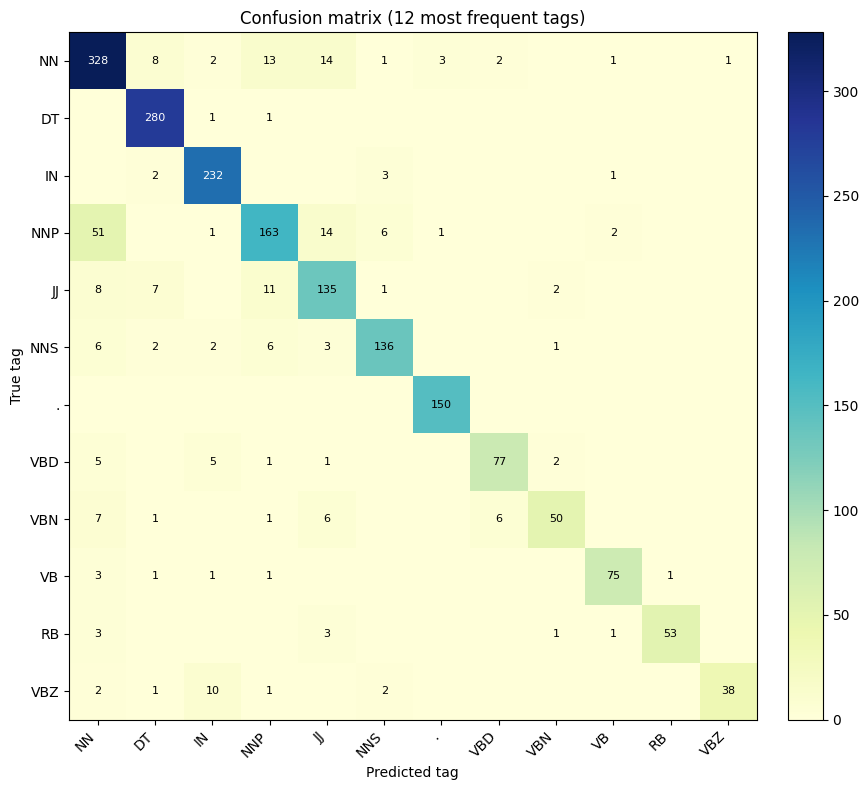

Saved -> results/confusion_matrix.png


In [32]:
import os
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix

# Focus on the 12 most frequent tags for a readable matrix
top_tags = [tag for tag, _ in Counter(y_true).most_common(12)]
cm = confusion_matrix(y_true, y_pred, labels=top_tags)

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(cm, cmap="YlGnBu")

ax.set_xticks(range(len(top_tags)))
ax.set_yticks(range(len(top_tags)))
ax.set_xticklabels(top_tags, rotation=45, ha="right")
ax.set_yticklabels(top_tags)
ax.set_xlabel("Predicted tag")
ax.set_ylabel("True tag")
ax.set_title("Confusion matrix (12 most frequent tags)")

for i in range(len(top_tags)):
    for j in range(len(top_tags)):
        value = cm[i, j]

        if value > 0:
            text_color = "white" if value > cm.max() * 0.5 else "black"
            ax.text(
                j, i, value,
                ha="center",
                va="center",
                color=text_color,
                fontsize=8
            )

plt.colorbar(image, fraction=0.046, pad=0.04)
plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/confusion_matrix.png", dpi=130)
plt.show()

print("Saved -> results/confusion_matrix.png")

### 6.6 Out-Of-Vocabulary (OOV) analysis

The out-of-vocabulary (OOV) rate is measured, and tagging accuracy on unseen words is compared with accuracy on seen words. The most frequent OOV misclassifications and examples are listed to link the accuracy gap to specific out-of-domain vocabulary.

In [ ]:
# A word is known if it appeared in the training data
def is_known(word):
    return word.lower() in known_words


seen_correct = seen_total = 0
oov_correct = oov_total = 0
oov_words = []

for section, combined in predictions:
    for word, gold_tag, pred_tag in combined:
        if is_known(word):
            seen_total += 1

            if gold_tag == pred_tag:
                seen_correct += 1
        else:
            oov_total += 1
            oov_words.append((word, gold_tag, pred_tag))

            if gold_tag == pred_tag:
                oov_correct += 1


total_tokens = seen_total + oov_total
oov_rate = oov_total / total_tokens

print(f"OOV rate                    : {oov_rate:.4f}  ({oov_total}/{total_tokens} words unseen)")
print(f"Accuracy on SEEN words      : {seen_correct/seen_total:.4f}  ({seen_correct}/{seen_total})")
print(f"Accuracy on UNSEEN (OOV)    : {oov_correct/oov_total:.4f}  ({oov_correct}/{oov_total})")
print(f"Accuracy gap                : {seen_correct/seen_total - oov_correct/oov_total:+.4f}")

OOV rate                    : 0.1371  (336/2451 words unseen)
Accuracy on SEEN words      : 0.8440  (1785/2115)
Accuracy on UNSEEN (OOV)    : 0.7798  (262/336)
Accuracy gap                : +0.0642


Find the most common OOV tagging mistakes


In [ ]:
from collections import Counter

oov_errors = Counter(
    (gold_tag, pred_tag)
    for word, gold_tag, pred_tag in oov_words
    if gold_tag != pred_tag
)

print("\nMost common OOV mistakes (true -> predicted):")

for (gold_tag, pred_tag), count in oov_errors.most_common(8):
    print(f"  {gold_tag:5} -> {pred_tag:5}  ({count} times)")


# Show a few incorrectly tagged OOV words
print("\nExample mistagged OOV words:")

for word, gold_tag, pred_tag in [item for item in oov_words if item[1] != item[2]][:10]:
    print(f"  {word:16} gold={gold_tag:5} pred={pred_tag}")


Most common OOV mistakes (true -> predicted):
  NNP   -> NN     (11 times)
  NN    -> JJ     (7 times)
  JJ    -> NN     (6 times)
  NN    -> NNP    (6 times)
  JJ    -> NNP    (5 times)
  NNP   -> NNS    (3 times)
  VBN   -> JJ     (3 times)
  NNS   -> NNP    (2 times)

Example mistagged OOV words:
  themes           gold=NNS   pred=NNP
  memoranda        gold=NNS   pred=NN
  rip-and-replace  gold=JJ    pred=NN
  Creatives        gold=NNP   pred=NNS
  Programme        gold=NNP   pred=NN
  comply           gold=VB    pred=RB
  whilst           gold=IN    pred=VB
  towards          gold=IN    pred=NNS
  app              gold=NN    pred=NNP
  Google           gold=NNP   pred=NN


### 6.7 Saving the Evaluation Results

All evaluation metrics such as overall accuracy, the ablation comparison, per-section accuracy, OOV analysis, and per-tag scores, are written to results/metrics.txt as a permanent record of the test results.

In [38]:
import os

os.makedirs("results", exist_ok=True)

with open("results/metrics.txt", "w", encoding="utf-8") as file:
    file.write("POS TAGGER — EVALUATION RESULTS\n")
    file.write("=" * 50 + "\n\n")

    file.write("OVERALL ACCURACY\n")
    file.write(f"  Full model (clues ON) : {acc_on:.4f}  ({correct}/{total})\n\n")

    file.write("MODEL COMPARISON (ABLATION)\n")
    file.write(f"  1. Baseline (most-frequent tag) : {baseline_acc:.4f}\n")
    file.write(f"  2. HMM + Viterbi, clues OFF     : {acc_off:.4f}\n")
    file.write(f"  3. Full model (clues ON)        : {acc_on:.4f}\n")
    file.write(f"  Context gain (1->2)             : {acc_off - baseline_acc:+.4f}\n")
    file.write(f"  Unknown-word gain (2->3)        : {acc_on - acc_off:+.4f}\n")
    file.write(f"  Total gain (1->3)               : {acc_on - baseline_acc:+.4f}\n\n")
    file.write(f"  Per-token accuracy    : {acc_on:.4f}  ({correct}/{total})\n")
    file.write(f"  Sentence-level accuracy: {sentence_accuracy:.4f}  ({fully_correct}/{len(predictions)})\n\n")

    file.write("PER-SECTION ACCURACY\n")

    for section in ["business", "politics", "sport", "local"]:
        accuracy = section_correct[section] / section_total[section]
        file.write(
            f"  {section:10}: {accuracy:.4f}  "
            f"({section_correct[section]}/{section_total[section]})\n"
        )

    file.write("\n")

    file.write("OUT-OF-VOCABULARY ANALYSIS\n")
    file.write(f"  OOV rate                : {oov_rate:.4f}  ({oov_total}/{total_tokens})\n")
    file.write(f"  Accuracy on SEEN words  : {seen_correct/seen_total:.4f}\n")
    file.write(f"  Accuracy on OOV words   : {oov_correct/oov_total:.4f}\n")
    file.write(
        f"  Accuracy gap            : "
        f"{seen_correct/seen_total - oov_correct/oov_total:+.4f}\n\n"
    )

    file.write("PER-TAG PRECISION / RECALL / F1\n")
    file.write(
        classification_report(
            y_true,
            y_pred,
            zero_division=0,
            digits=3
        )
    )

print("Metrics saved -> results/metrics.txt")

Metrics saved -> results/metrics.txt


## 7. Results Summary and Error Analysis

### 7.1 Summary of Results

The POS tagger was evaluated on the 150 hand-annotated Daily Mirror sentences
(2,451 tokens) by comparing its predictions against the gold standard. The full
model achieved a per-token accuracy of _____%, correctly tagging _____ of 2,451
word tokens, exceeding the most-frequent-tag baseline of 79.89% by _____
percentage points. The main results are summarised in the tables below.

**Overall Performance**
| Metric | Result |
|:---|:---|
| Per-token accuracy | **83.52%** (2047 / 2451) |
| Baseline accuracy | 79.89% |
| Improvement over baseline | +3.63% |

**Sentence Level Performace**

Sentence-level accuracy counts a sentence as correct only if all its words are tagged right. It is stricter than per-token accuracy, which credits each correct word individually.
| Metric | Result |
|:---|:---|
| Sentence-level accuracy | 9.33% (14 / 150 fully correct) |

**Ablation Study**
| Configuration | Accuracy |
|:---|:---|
| Baseline (most-frequent tag) | 79.89% |
| HMM + Viterbi (clues off) | 75.68% |
| Full model (clues on) | **83.52%** |

**Accuracy by Section**
| Section | Accuracy |
|:---|:---|
| Sport | 84.78% |
| Politics | 84.13% |
| Business | 82.91% |
| Local | 81.59% |

**Vocabulary Coverage**
| Metric | Result |
|:---|:---|
| OOV rate | 13.71% (336 / 2451) |
| Accuracy — seen words | 84.40% |
| Accuracy — OOV words | 77.98% |
| Seen vs OOV gap | +6.42% |

Per-token accuracy was 83.52%, whereas sentence-level accuracy — the proportion
of sentences tagged with no errors at all — was only _____%. This large gap is
expected, because _____ [YOUR EXPLANATION: with ~16 words per sentence, why does
a high per-word accuracy still leave most sentences with at least one error?].
This is why per-token accuracy is the standard metric for POS tagging.

### 7.2 The Role of Unknown-Word Handling

The ablation study revealed an important result. The HMM with contextual
decoding but no unknown-word clues scored 75.68% — _____ [above / below] the
most-frequent-tag baseline of 79.89%. This happened because _____ [YOUR
EXPLANATION: what does the tagger do with an unseen word when clues are off, and
how does the Viterbi sequence spread that mistake to neighbouring words?].

Enabling the data-driven unknown-word mechanism raised accuracy to 83.52%, a
gain of _____ percentage points. This shows that _____ [YOUR EXPLANATION: which
component contributed most to performance on this out-of-domain text, and why?].

### 7.3 Error Analysis: Proper Nouns and Vocabulary

The weakest category was NNP (proper nouns), with a recall of only 0.665. The
confusion matrix showed that 51 proper nouns were mistagged as NN. Inspection
revealed these were mostly _____ [YOUR WORDS: what kind of words? give 2–3 real
examples from your data], which never appeared in the _____ [which training
corpus, from what year and domain?].

This explains why the _____ [which section] section scored lowest, since it
contained the most _____ [what kind of words?].

By contrast, the tagger performed very well on closed-class categories such as
CC, DT and PRP, all with F1 above 0.93. This is because _____ [YOUR EXPLANATION:
what is different about these categories' vocabularies that makes them easy to
learn?].

A further observation is that some errors came from vocabulary differences
between British/Sri Lankan and American English. For example, "whilst" and
"towards" were unseen in training and mistagged. This shows that domain mismatch
affects not only _____ [what?] but also _____ [what?].

### 7.4 Parsing Coverage

The PCFG parser produced correct trees for some sentences, such as "The White
House rejected the findings." However, it failed on sentences containing _____
[what caused the failures?], such as "_____ [an example that did not parse]."
This reflects _____ [YOUR EXPLANATION: what limitation of a grammar induced from
a small corpus?].

### 7.5 Limitations and Future Work

The main limitations of this system are:

- The training data was the NLTK Penn Treebank sample (~3,900 sentences), which
  is _____ [why is its small size a limitation for tagging unseen text?].
- There was a domain mismatch between the training data (_____ [describe it])
  and the test data (_____ [describe it]).
- Evaluation measured _____ [which metric?]; a full parse-tree (PARSEVAL)
  evaluation was not performed because _____ [why not — what would it require?].
- The HMM is a relatively simple model. More advanced approaches such as _____
  [name 1–2, e.g. CRF or neural/transformer taggers] would likely improve
  accuracy, especially on unseen vocabulary.

### 7.6 Conclusion

This project built a statistical POS tagger and PCFG parser from the Penn
Treebank and evaluated them on 150 Daily Mirror sentences. The tagger reached
83.52% per-token accuracy, and analysis showed that the main challenge was _____
[what, in one phrase?], driven by _____ [what underlying cause?]. Overall, the
results demonstrate that _____ [YOUR ONE-SENTENCE TAKEAWAY: what did you learn
about statistical tagging on out-of-domain text?].